# Exercises XP: Time Series with LSTM

# Part 1: Data Import and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)

# Set this to your dataset path if different
DATA_PATH = Path('household_power_consumption.txt')

# Robust loader for semicolon separated file with ? as NA
parse_cols = {
    'Global_active_power': 'float64',
    'Global_reactive_power': 'float64',
    'Voltage': 'float64',
    'Global_intensity': 'float64',
    'Sub_metering_1': 'float64',
    'Sub_metering_2': 'float64',
    'Sub_metering_3': 'float64',
}
usecols = ['Date','Time'] + list(parse_cols.keys())

df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],
    usecols=usecols,
    dtype=parse_cols,
    parse_dates={'Datetime': ['Date','Time']},
    infer_datetime_format=True,
    dayfirst=True,
)

df = df.set_index('Datetime').sort_index()
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

/tmp/ipython-input-3109937490.py:24: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipython-input-3109937490.py:24: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(


Shape: (538186, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


,0
Global_active_power,float64
Global_reactive_power,float64
Voltage,float64
Global_intensity,float64
Sub_metering_1,float64
Sub_metering_2,float64
Sub_metering_3,float64


# Part 2: Handling Missing Values

In [4]:
# show missing summary, impute with column means, verify
df.info()

missing_before = df.isna().sum().sort_values(ascending=False)
print('Missing before:'); display(missing_before[missing_before>0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

missing_after = df.isna().sum().sum()
print('Total missing after fill:', int(missing_after))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 538186 entries, 2006-12-16 17:24:00 to 2007-12-25 11:09:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Global_active_power    534251 non-null  float64
 1   Global_reactive_power  534251 non-null  float64
 2   Voltage                534251 non-null  float64
 3   Global_intensity       534250 non-null  float64
 4   Sub_metering_1         534250 non-null  float64
 5   Sub_metering_2         534250 non-null  float64
 6   Sub_metering_3         534250 non-null  float64
dtypes: float64(7)
memory usage: 32.8 MB
Missing before:


,0
Sub_metering_2,3936
Sub_metering_1,3936
Global_intensity,3936
Sub_metering_3,3936
Voltage,3935
Global_active_power,3935
Global_reactive_power,3935


Total missing after fill: 0


# Part 3: Data Visualization

In [5]:
def plot_daily_sum_and_mean(series, title_prefix='Global_active_power'):
    daily = series.resample('1D')
    s = daily.sum(min_count=1)
    m = daily.mean()
    plt.figure(figsize=(8,3))
    plt.plot(s.index, s.values)
    plt.title(f'{title_prefix} daily sum')
    plt.xlabel('date'); plt.ylabel('sum'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values)
    plt.title(f'{title_prefix} daily mean')
    plt.xlabel('date'); plt.ylabel('mean'); plt.tight_layout(); plt.show()

def plot_daily_mean_std(series, title_prefix='Global_intensity'):
    daily = series.resample('1D')
    m = daily.mean()
    sd = daily.std()
    plt.figure(figsize=(8,3))
    plt.plot(m.index, m.values, label='mean')
    plt.plot(sd.index, sd.values, label='std')
    plt.title(f'{title_prefix} daily mean and std')
    plt.xlabel('date'); plt.ylabel('value')
    plt.legend(); plt.tight_layout(); plt.show()

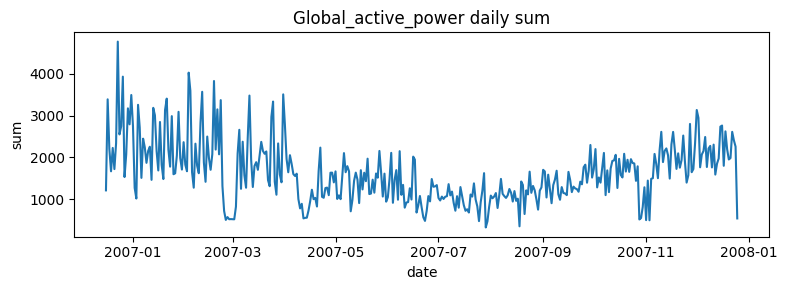

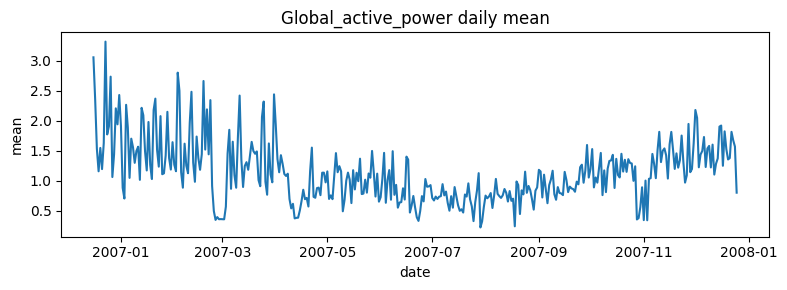

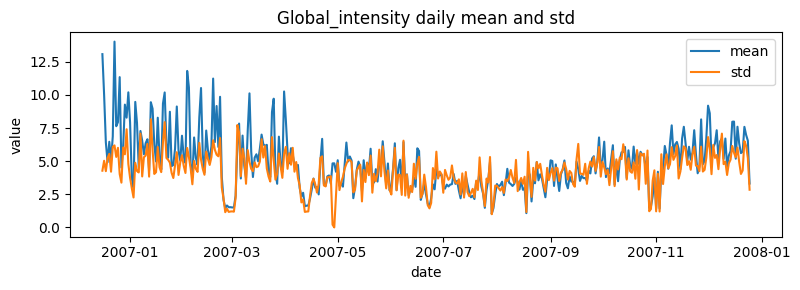

In [6]:
# visualize daily aggregations
plot_daily_sum_and_mean(df['Global_active_power'], title_prefix='Global_active_power')
plot_daily_mean_std(df['Global_intensity'], title_prefix='Global_intensity')

# Part 4: Data Preprocessing for LSTM
**Learning point**  
LSTMs consume sequences with shape [batch, time, features]. You must build sliding windows. Use a lookback window and predict the next step.

![image.png](https://github.com/user-attachments/assets/be3e815f-2aff-4e8d-ac48-eca27b1c729c)


In [12]:
from sklearn.preprocessing import MinMaxScaler

def make_windows(arr_2d, window=48, horizon=1):
    X, y = [], []
    for i in range(len(arr_2d) - window - horizon + 1):
        X.append(arr_2d[i:i+window])
        y.append(arr_2d[i+window:i+window+horizon, 0])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    return X, y

def time_train_test_split(df, split_ratio=0.8):
    n = len(df)
    k = int(n * split_ratio)
    return df.iloc[:k].copy(), df.iloc[k:].copy()

feat_cols = ['Global_active_power','Global_reactive_power','Voltage','Global_intensity',
             'Sub_metering_1','Sub_metering_2','Sub_metering_3']
df_feats = df[feat_cols].copy()

df_tr, df_te = time_train_test_split(df_feats, split_ratio=0.8)

scaler = MinMaxScaler()
tr_scaled = scaler.fit_transform(df_tr.values)
te_scaled = scaler.transform(df_te.values)

WINDOW = 48
HORIZON = 1
X_tr, y_tr = make_windows(tr_scaled, window=WINDOW, horizon=HORIZON)
X_te, y_te = make_windows(te_scaled, window=WINDOW, horizon=HORIZON)

print('Train windows:', X_tr.shape, 'Train targets:', y_tr.shape)
print('Test windows:', X_te.shape, 'Test targets:', y_te.shape)

Train windows: (430500, 48, 7) Train targets: (430500, 1)
Test windows: (107590, 48, 7) Test targets: (107590, 1)


I chose Global_active_power as the target because it represents the total household electricity consumption, which is the main variable of interest. The remaining features (reactive power, voltage, intensity, and sub-meterings) provide contextual information that helps the LSTM model learn consumption patterns over time



# Part 5: Building an LSTM Model

In [13]:
# define and compile the LSTM
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(WINDOW, X_tr.shape[-1])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(HORIZON),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6: Training and Evaluating the LSTM Model

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=10, batch=256):
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    h = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                  epochs=epochs, batch_size=batch, callbacks=[es, rl], verbose=2)
    plt.figure(figsize=(6,4))
    plt.plot(h.history['loss'], label='loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()
    return h

Epoch 1/15
1682/1682 - 161s - 95ms/step - loss: 9.0441e-04 - mae: 0.0132 - val_loss: 7.2182e-04 - val_mae: 0.0133 - learning_rate: 1.0000e-03
Epoch 2/15
1682/1682 - 153s - 91ms/step - loss: 7.3403e-04 - mae: 0.0115 - val_loss: 7.0156e-04 - val_mae: 0.0112 - learning_rate: 1.0000e-03
Epoch 3/15
1682/1682 - 153s - 91ms/step - loss: 7.1011e-04 - mae: 0.0111 - val_loss: 6.8665e-04 - val_mae: 0.0112 - learning_rate: 1.0000e-03
Epoch 4/15
1682/1682 - 150s - 89ms/step - loss: 6.8852e-04 - mae: 0.0105 - val_loss: 6.6702e-04 - val_mae: 0.0115 - learning_rate: 5.0000e-04
Epoch 5/15
1682/1682 - 152s - 90ms/step - loss: 6.8283e-04 - mae: 0.0105 - val_loss: 6.5900e-04 - val_mae: 0.0101 - learning_rate: 5.0000e-04
Epoch 6/15
1682/1682 - 153s - 91ms/step - loss: 6.7055e-04 - mae: 0.0102 - val_loss: 6.7014e-04 - val_mae: 0.0104 - learning_rate: 2.5000e-04
Epoch 7/15
1682/1682 - 152s - 91ms/step - loss: 6.6664e-04 - mae: 0.0101 - val_loss: 6.6038e-04 - val_mae: 0.0107 - learning_rate: 2.5000e-04
Epoch 

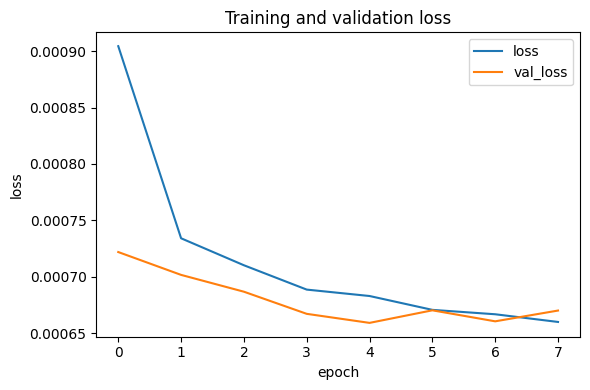

{'test_mse': 0.0006589972181245685, 'test_mae': 0.010062852874398232}


In [15]:
# train and evaluate
hist = fit_and_plot(model, X_tr, y_tr, X_te, y_te, epochs=15, batch=256)
eval_mse, eval_mae = model.evaluate(X_te, y_te, verbose=0)
print({'test_mse': float(eval_mse), 'test_mae': float(eval_mae)})